# ASSIGNMENT: METRIC ANOMALY DETECTION
---

## PHASE 1: EDA & DATA

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score

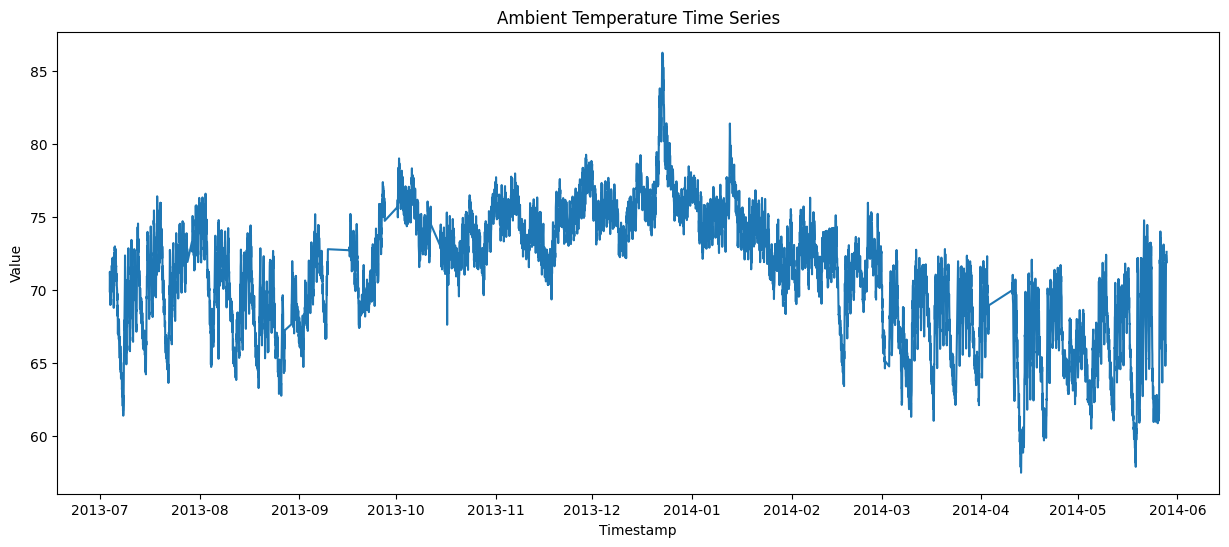

In [154]:

# Load data
df = pd.read_csv('Data/ambient_temperature_system_failure.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])

# Plot raw time series 
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['value']) 

plt.title('Ambient Temperature Time Series')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.show()

In [155]:
# Basic stats

stats = {
    'Mean': df['value'].mean(),
    'Std': df['value'].std(),
    'Skewness': skew(df['value']),
    'Min': df['value'].min(),
    'Max': df['value'].max()
}

stats_df = pd.DataFrame(stats, index=['Value']).T
print(stats_df)


              Value
Mean      71.242433
Std        4.247509
Skewness  -0.392532
Min       57.458406
Max       86.223213


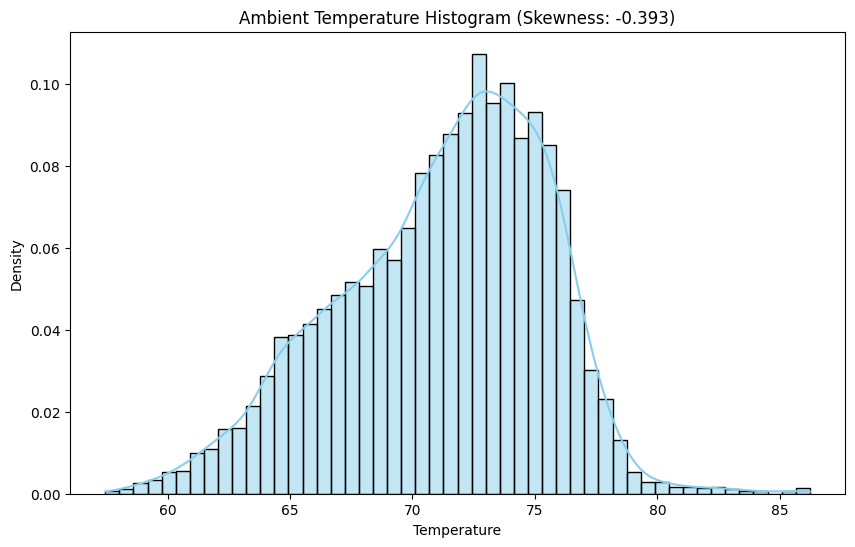

In [156]:
# Histogram + Density
plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True, bins=50, color='skyblue', stat="density")
plt.title(f'Ambient Temperature Histogram (Skewness: {skew(df["value"]):.3f})')
plt.xlabel('Temperature')
plt.ylabel('Density')
plt.show()

Skewness = -0.39 < 0 --> Data gần Gaussian (|skewness| < 0.5)

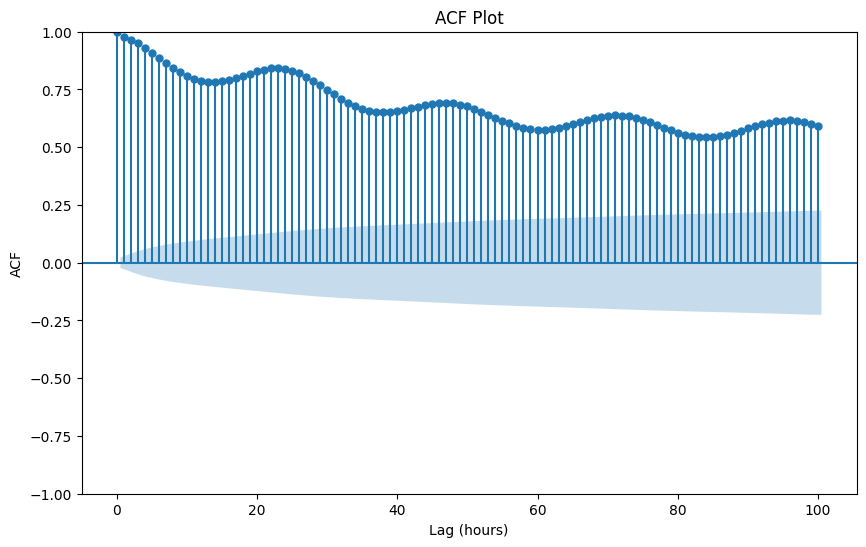

In [157]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_acf(df['value'], lags=100, ax=ax)

plt.title('ACF Plot')
plt.xlabel('Lag (hours)')
plt.ylabel('ACF')

plt.show()

Data có seasonal do biểu đồ ACF hiển thị các đỉnh nhọn nhấp nhô

Đỉnh nhọn đầu tiên (sau lag 0) xuất hiện tại Lag 24. Các đỉnh tiếp theo xuất hiện tại Lag 48, 72, 96 nên Period sẽ là 24 giờ

Kết luận:

Dữ liệu có tính seasonal và gần Gaussian

--> STL Decomposition + 3σ sẽ là phương pháp phù hợp nhất

## PHASE 2: IMPLEMENT 2 DETECTORS

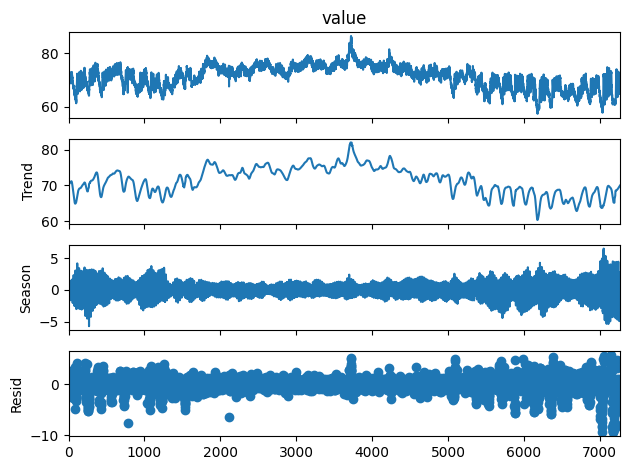

Tổng data: 7267
Tổng số anomaly: 182


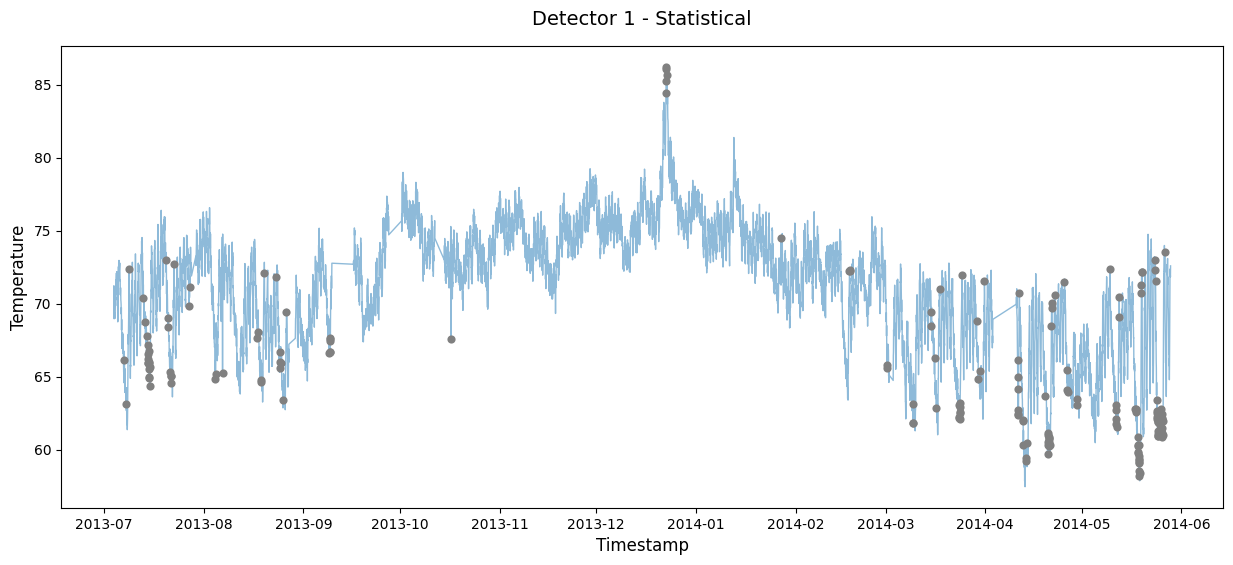

In [158]:
# Detector 1 — Statistical: STL + 3σ
stl = STL(df['value'], period=24, robust=True)
res = stl.fit()
df['residual'] = res.resid
res.plot()
plt.show()

residual = df['residual'].values
resid_mean = np.mean(residual)
resid_std = np.std(residual)

threshold = 3.0

df['lower_bound'] = resid_mean - threshold * resid_std
df['upper_bound'] = resid_mean + threshold * resid_std 

# Tìm anomaly
df['is_anomaly_stl'] = np.abs(residual - resid_mean) > threshold * resid_std

total_anomalies = df['is_anomaly_stl'].sum()
print(f"Tổng data: {len(df)}")
print(f"Tổng số anomaly: {total_anomalies}")

plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['value'], alpha=0.5, linewidth=1, label='Real Temp')

anomalies_df = df[df['is_anomaly_stl'] == True]
plt.scatter(anomalies_df['timestamp'], anomalies_df['value'], 
            color='grey', marker='o', s=15, linewidths=2, label='Anomaly', zorder=5)

plt.title("Detector 1 - Statistical", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.show()



Contamination = 0.01
- Anomalies: 73
- Precision: 0.137
- Recall:    0.055
- F1-Score:  0.078

Contamination = 0.02
- Anomalies: 145
- Precision: 0.124
- Recall:    0.099
- F1-Score:  0.110

Contamination = 0.05
- Anomalies: 363
- Precision: 0.196
- Recall:    0.390
- F1-Score:  0.261


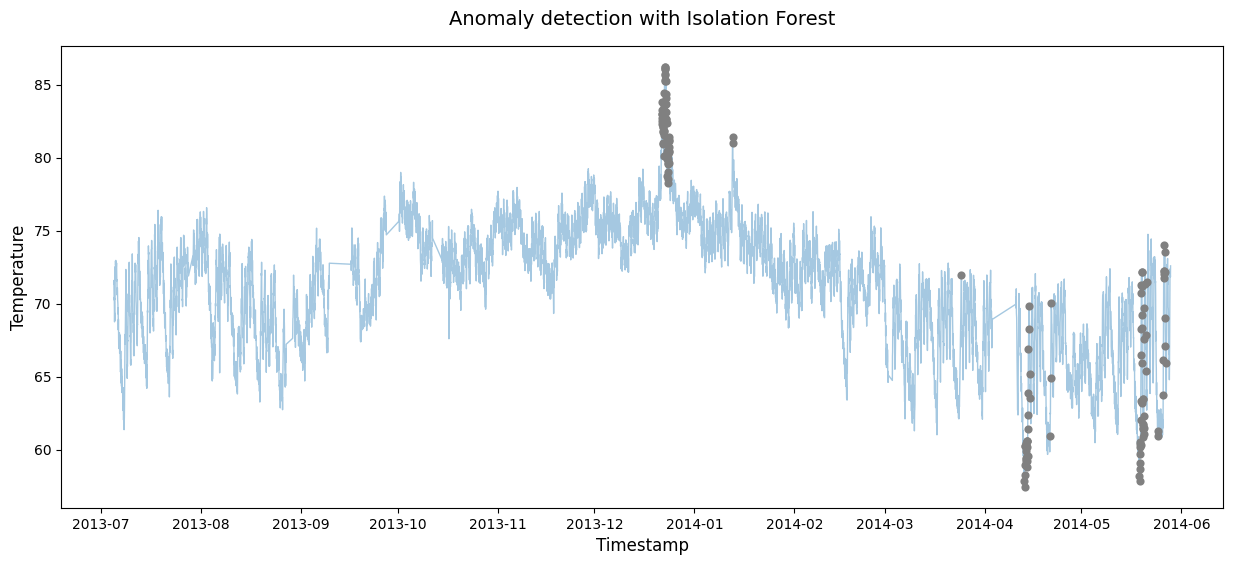

In [159]:
# IF time table
s = pd.Series(df['value'])

window_day = 24 

df_features = pd.DataFrame({
    'timestamp': df['timestamp'],
    'value': s,
    'is_anomaly_stl': df['is_anomaly_stl'],
    'rolling_mean_day': s.rolling(window_day).mean(), 
    'rolling_std_day': s.rolling(window_day).std(), 
    'rate_of_change': s.diff(),
    'rate_of_change_6h': s.diff(6), 
    'lag_1': s.shift(1),
    'lag_24': s.shift(window_day), 
})

df_features = df_features.dropna().reset_index(drop=True)

X = df_features[['value', 'rolling_mean_day', 'rolling_std_day', 
                 'rate_of_change', 'rate_of_change_6h', 'lag_1', 'lag_24']]


# Tune contamination parameter: thử 0.01, 0.02, 0.05
y_true = df['is_anomaly_stl'].iloc[24:].astype(int).values

contamination_list = [0.01, 0.02, 0.05]
results = []


for contam in contamination_list:
    clf = IsolationForest(
        n_estimators=200,  
        contamination=contam, 
        max_features=1.0, 
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X)
    
    preds = clf.predict(X)
    y_pred = np.where(preds == -1, 1, 0)
    df_features[f'is_anomaly_iforest_{contam}'] = y_pred
    
    # Tìm Precision và Recall và f1
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    results.append({
        'Contamination': contam,
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3),
        'Detected Anomalies': np.sum(y_pred)
    })
    
    print(f"\nContamination = {contam}")
    print(f"- Anomalies: {np.sum(y_pred)}")
    print(f"- Precision: {precision:.3f}")
    print(f"- Recall:    {recall:.3f}")
    print(f"- F1-Score:  {f1:.3f}")
    
# DeDetector 2 — ML: Isolation Forest
plot_contam = 0.02

clf_plot = IsolationForest(
    n_estimators=200,  
    contamination=plot_contam, 
    max_features=1.0, 
    random_state=42,
    n_jobs=-1
)
clf_plot.fit(X)

preds_plot = clf_plot.predict(X)
df_features['is_anomaly_iforest'] = np.where(preds_plot == -1, 1, 0)

plt.figure(figsize=(15, 6))


plt.plot(df_features['timestamp'], df_features['value'], 
         color='tab:blue', alpha=0.4, linewidth=1, label='Real Temp')

# Tìm anomaly
anomalies_iforest = df_features[df_features['is_anomaly_iforest'] == 1]
plt.scatter(anomalies_iforest['timestamp'], anomalies_iforest['value'], 
            color='grey', marker='o', s=15, linewidths=2, label='Anomaly (Isolation Forest)', zorder=5)


plt.title(f"Anomaly detection with Isolation Forest", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)

plt.show()

### Cho mỗi detector: tính precision, recall, F1 dùng ground truth label từ NAB

In [160]:
# Ground truth
nab_anomalies = ['2013-12-22 20:00:00', '2014-04-13 09:00:00']
nab_timestamps = pd.to_datetime(nab_anomalies)


df['ground_truth'] = df['timestamp'].isin(nab_timestamps).astype(int)
df_features['ground_truth'] = df_features['timestamp'].isin(nab_timestamps).astype(int)
y_true = df_features['ground_truth'].values

# Tính precision, recall, F1 cho detector 1
y_pred_stl = df_features['timestamp'].isin(df[df['is_anomaly_stl'] == True]['timestamp']).astype(int).values

p1 = precision_score(y_true, y_pred_stl, zero_division=0)
r1 = recall_score(y_true, y_pred_stl, zero_division=0)
f1_d1 = f1_score(y_true, y_pred_stl, zero_division=0)

# Tính precision, recall, F1 cho detector 2
iforest_metrics = []

for contam in [0.01, 0.02, 0.05]:
    col_name = f'is_anomaly_iforest_{contam}'
    y_pred_if = df_features[col_name].values
    
    p_if = precision_score(y_true, y_pred_if, zero_division=0)
    r_if = recall_score(y_true, y_pred_if, zero_division=0)
    f1_if = f1_score(y_true, y_pred_if, zero_division=0)
    
    iforest_metrics.append({
        'Detector': f'Isolation Forest ({contam})',
        'Precision': round(p_if, 3),
        'Recall': round(r_if, 3),
        'F1-Score': round(f1_if, 3),
        'Anomalies Detected': np.sum(y_pred_if),
        'False Alarms': np.sum((y_pred_if == 1) & (y_true == 0))
    })

# SS giữa 2 detector 
summary_list = [{
    'Detector': 'Detector 1 (STL + 3σ)',
    'Precision': round(p1, 3),
    'Recall': round(r1, 3),
    'F1-Score': round(f1_d1, 3),
    'Anomalies Detected': np.sum(y_pred_stl),
    'False Alarms': np.sum((y_pred_stl == 1) & (y_true == 0))
}] + iforest_metrics

df_metrics_final = pd.DataFrame(summary_list)


print(df_metrics_final.to_string(index=False))

               Detector  Precision  Recall  F1-Score  Anomalies Detected  False Alarms
  Detector 1 (STL + 3σ)      0.005     0.5     0.011                 182           181
Isolation Forest (0.01)      0.014     0.5     0.027                  73            72
Isolation Forest (0.02)      0.014     1.0     0.027                 145           143
Isolation Forest (0.05)      0.006     1.0     0.011                 363           361


### Plot: original series + anomalies highlighted cho cả 2 detector (2 subplot, giống hình section 6)

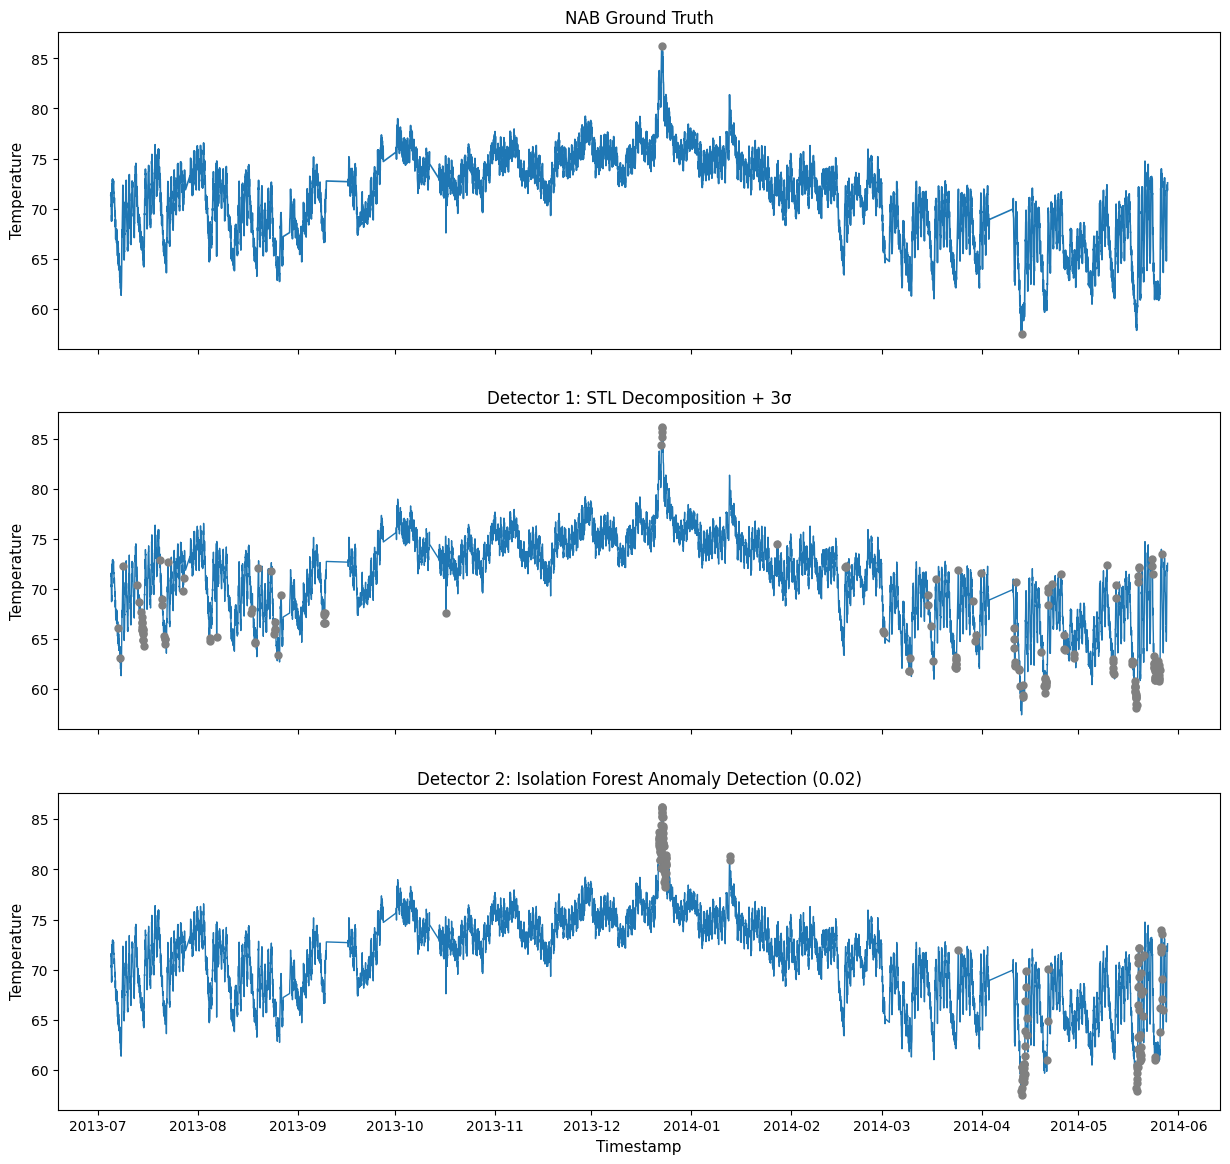

In [161]:
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

# ground truth labels
ax1.plot(df_features['timestamp'], df_features['value'], linewidth=1.2, label='Real Temp')
nab_real_anomalies = df_features[df_features['ground_truth'] == 1]
ax1.scatter(nab_real_anomalies['timestamp'], nab_real_anomalies['value'], 
            color='grey', marker='o', s=25, label='NAB Ground Truth', zorder=5)

# Set labels
ax1.set_title("NAB Ground Truth", fontsize=12)
ax1.set_ylabel("Temperature", fontsize=11)


# Detector 1 — Statistical: STL + 3σ
ax2.plot(df_features['timestamp'], df_features['value'], linewidth=1, label='Real Temp')
anomalies_stl = df_features[df_features['is_anomaly_stl'] == True]
ax2.scatter(anomalies_stl['timestamp'], anomalies_stl['value'], 
            color='grey', marker='o', s=25, label='Điểm bất thường (STL)', zorder=5)

# Set labels
ax2.set_title("Detector 1: STL Decomposition + 3σ", fontsize=12)
ax2.set_ylabel("Temperature", fontsize=11)



# Detector 2 — ML: Isolation Forest
ax3.plot(df_features['timestamp'], df_features['value'], linewidth=1, label='Real Temp')
anomalies_iforest = df_features[df_features['is_anomaly_iforest_0.02'] == 1]
ax3.scatter(anomalies_iforest['timestamp'], anomalies_iforest['value'], 
            color='grey', marker='o', s=25, label='Điểm bất thường (IF)', zorder=5)

# Set labels
ax3.set_title("Detector 2: Isolation Forest Anomaly Detection (0.02)", fontsize=12)
ax3.set_xlabel("Timestamp", fontsize=11)
ax3.set_ylabel("Temperature", fontsize=11)

plt.show()

## Phase 3: So Sánh & Reflection 
### Tạo bảng so sánh 2 detector

| Metric | Detector 1 (STL + 3σ) | Detector 2 (IF - 0.02) |
| :--- | :---: | :---: |
| **Precision** | 0.005 | 0.014 |
| **Recall** | 0.5 | 1.0 |
| **F1-Score** | 0.011 | 0.027 |
| **False Alarms** | 181 | 143 |


Chọn IF contamination 0.02 vì nó vừa có recall cao (1) thay vì 0.01 recall thấp (0.5) và cũng không chọn 0.05 vì false alarm quá cao

### Thử tune threshold / window size / contamination → ghi lại kết quả (ít nhất 3 lần tune)

Contamination = 0.01
- Anomalies: 73
- Precision: 0.137
- Recall:    0.055
- F1-Score:  0.078

Contamination = 0.02
- Anomalies: 145
- Precision: 0.124
- Recall:    0.099
- F1-Score:  0.110

Contamination = 0.05
- Anomalies: 363
- Precision: 0.196
- Recall:    0.390
- F1-Score:  0.261

## Model artifacts: file .pkl hoặc .joblib của Isolation Forest đã train (nhỏ, < 1MB)

In [162]:
contam = 0.02

# Train lại với contamination = 0.02
clf = IsolationForest(
    n_estimators=200,  
    contamination=contam, 
    max_features=1.0, 
    random_state=42,
    n_jobs=-1
)
clf.fit(X)

# Lưu model
file = 'IF_Model_Artifacts.joblib'
joblib.dump(clf, file)
print(f"Finished")

Finished
